# Numerical integration

## Introduction

In this chapter, for a given function $f(x)$ we will compute the definite integral:

$$\int_a^b\,f(x)\,\textrm{d}x$$

where $a$ and $b$ are the limits of integration, and $f(x)$ are the function values obtained either from a table of values or from an analytical function.

In numerical integration, the integral is estimated by $I$, and the following holds:

$$\int_a^b\,f(x)\,\textrm{d}x= I + E,$$

where $E$ is the error of the integral estimate.

We will compute the numerical integral based on a discrete sum:

$$I=\sum_{i=0}^{m}A_i\,f(x_i),$$

where $A_i$ are the weights, $x_i$ are the nodes on the interval $[a, b]$, and $m+1$ is the number of nodes.

We will look at two different approaches to numerical integration:

1. the *Newton-Cotes approach*, which is based on equidistant nodes (a constant integration step), and
2. the *Gaussian integration approach*, where the nodes are placed so as to achieve exactness for polynomials.

### Motivational example

For numerical integration, we will use a concrete example to guide us:

$$\int_1^2 x\,\sin(x)\,\textrm{d}x$$

Let us prepare the nodes. Let the basic step be $h=0.25$; in this case we have four subintervals and five nodes, at step $2h$ there are three nodes, and at step $4h$ only two (the endpoints):

In [1]:
import numpy as np
xg, hg = np.linspace(1, 2, 100, retstep=True) # dense points (for plotting)
x2v, h2v = np.linspace(1, 2, 2, retstep=True)  # step h2v = 1 (2 nodes)
x3v, h3v = np.linspace(1, 2, 3, retstep=True)  # step h3v = 0.5 (3 nodes)
x4v, h4v = np.linspace(1, 2, 4, retstep=True)  # step h4v = 0.33.. (4 nodes)
x5v, h5v = np.linspace(1, 2, 5, retstep=True)  # step h5v = 0.25 (5 nodes)

Let us also prepare the function values:

In [2]:
yg = xg * np.sin(xg)
y2v = x2v * np.sin(x2v)
y3v = x3v * np.sin(x3v)
y4v = x4v * np.sin(x4v)
y5v = x5v * np.sin(x5v)

Let us prepare a plot of the data:

In [3]:
import matplotlib.pyplot as plt
%matplotlib inline
def fig_motivation():
    plt.fill_between(xg, yg, alpha=0.25, facecolor='r')
    plt.annotate(r'$\int_1^2\,x\,\sin(x)\,\mathrm{d}x$', (1.3, 0.5), fontsize=22)
    plt.plot(xg, yg, lw=3, alpha=0.5, label=r'$x\,\sin(x)$')
    plt.plot(x2v, y2v, 's', alpha=0.5, label=f'$h={h2v}$', markersize=14)
    plt.plot(x3v, y3v, 'o', alpha=0.5, label=f'$h={h3v}$', markersize=10)
    plt.legend(loc=(1.01, 0))
    plt.ylim(0, 2)
    plt.show()

Let us display the data:

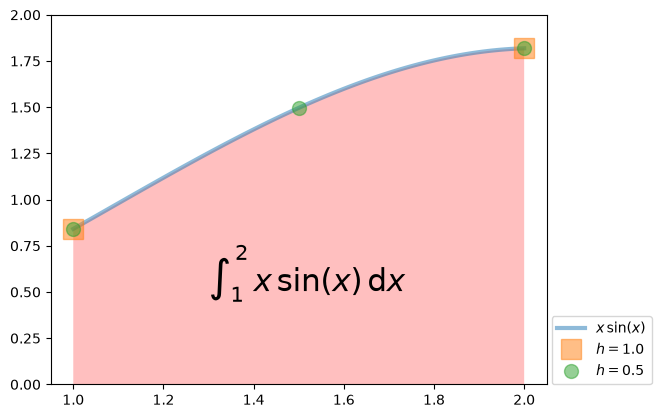

In [4]:
fig_motivation()

Let us compute the exact result analytically:

In [5]:
import sympy as sym
sym.init_printing()
x = sym.symbols('x')
I_exact = float(sym.integrate(x*sym.sin(x), (x, 1, 2)).evalf())
I_exact

## Newton-Cotes approach

The figure shows a general case in which the distance between the nodes $x_i$ is equal to $h$ (this is an **equidistant partition**).
![Integration](./fig/integriranje.png)

In this chapter we will first look at the trapezoidal and the composite trapezoidal rule, and later the Simpson's and Romberg methods will follow.

### Trapezoidal rule

The trapezoidal rule interpolates the values of the integrand $f(x)$ on the (sub)interval $[x_0, x_1]$ with a linear function. For two nodes, this means that we approximate the area under the graph of the function as:

$$I_{\textrm{trapezno}}=\sum_{i=0}^{1}A_i\,f(x_i)=\frac{h}{2}\cdot\left(f(x_0)+f(x_1)\right).$$

And the weights are:

$$A_0 = A_1 = \frac{1}{2}\,h.$$

#### Numerical implementation

The numerical implementation is:

In [6]:
def trapezoidal(y, h):
    """
    Trapezoidal rule of integration.

    :param y: function values
    :param h: integration step
    """
    return (y[0] + y[-1])*h/2

#### Numerical example

In our concrete case this means that we weight the first and last function value by $h/2$. In our example $h=1$:

In [7]:
I_trapezoidal = trapezoidal(y2v, h=h2v)
I_trapezoidal

Let us prepare a figure:

In [8]:
def fig_trapezoidal():
    plt.fill_between(x2v, y2v, alpha=0.25, facecolor='r')
    plt.vlines(x2v, 0, y2v, color='r', linestyles='dashed', lw=1)
    plt.annotate('$I_{\\mathrm{trapezno}}$', (1.4, 0.5), fontsize=22)
    plt.annotate('Error', fontsize=20, xy=(1.5, 1.4), xytext=(1.6, 1.8),
            arrowprops=dict(facecolor='gray', shrink=0.05))
    plt.plot(xg, yg, lw=3, alpha=0.5, label='$x\\,\\sin(x)$')
    plt.plot(x2v, y2v, 'o', alpha=0.5, label=f'$h={h2v}$')
    plt.legend(loc=(1.01, 0))
    plt.ylim(0, 2)
    plt.show()

We display:

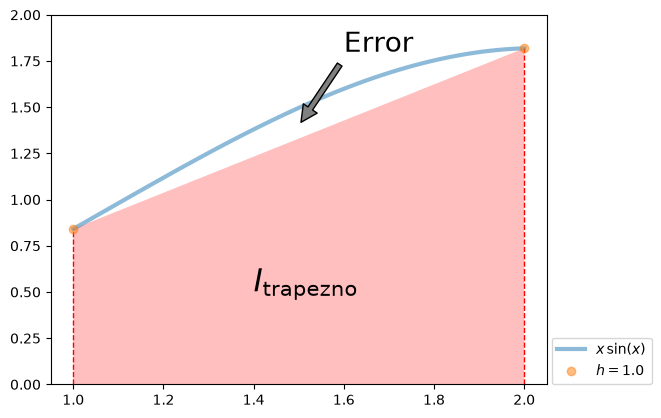

In [9]:
fig_trapezoidal()

#### Error of the trapezoidal rule

The difference between the analytical value of the integral and the numerical approximation $I$ is the error of the method:

$$E = \int_a^bf(x)\,d x-I,$$

If the function $f(x)$ is at least twice differentiable, one can derive (see, e.g., the reference: Burden, Faires, Burden: Numerical Analysis 10th Ed) an error estimate that applies only to the trapezoidal approximation over the entire integration interval:

$$E_{\textrm{trapezno}}=-\frac{h^3}{12}f''(\xi),$$

where $h=b-a$ and $\xi$ is an unknown value on the interval $[a,b]$.

### Composite trapezoidal rule

If we divide the interval $[a, b]$ into $n$ subintervals and apply the trapezoidal rule of integration on each of them, we speak of the *composite trapezoidal rule*.

In this case, for each subinterval $i$ we apply the trapezoidal rule, and thus for the bounds of the subinterval $x_i$ and $x_{i+1}$ we use the weights $A_i=A_{i+1}=h/2$. Since the interior nodes are doubled, it follows that:

$$A_0=A_{n}=\frac{h}{2}\quad\textrm{and for the other nodes:}\quad A_i=h.$$

Here we have assumed subintervals of equal width:

$$h=\frac{x_{n}-x_0}{n}$$

It therefore follows that:

$$I_{\textrm{trapezno sest}}=\sum_{i=0}^{n}A_i\,f(x_i)=\left(\frac{y_0}{2} + y_1+y_2+\cdots+y_{n-1}+\frac{y_{n}}{2}\right)\,h.$$

#### Numerical implementation

The numerical implementation is:

In [10]:
def trapezoidal_comp(y, h):
    """
    Composite trapezoidal rule of integration.

    :param y: function values
    :param h: integration step
    """
    return (np.sum(y) - 0.5*y[0] - 0.5*y[-1])*h

#### Numerical example

Above we already prepared the data for two subintervals (three nodes):

In [11]:
x3v

array([1. , 1.5, 2. ])

In [12]:
h3v

Let us compute the estimate of the integral with the composite trapezoidal rule:

In [13]:
I_trapezoidal_comp = trapezoidal_comp(y3v, h=h3v)
I_trapezoidal_comp

Let us prepare a figure:

In [14]:
def fig_trapezoidal_comp():
    plt.fill_between(x3v, y3v, alpha=0.25, facecolor='r')
    plt.vlines(x3v, 0, y3v, color='r', linestyles='dashed', lw=1)
    plt.annotate('$I_{\\mathrm{trapezno\\;sestavljeno}}$', (1.2, 0.5), fontsize=22)
    plt.annotate('Error', fontsize=20, xy=(1.75, 1.68), xytext=(1.4, 1.8),
            arrowprops=dict(facecolor='gray', shrink=0.05))
    plt.annotate('Error', fontsize=20, xy=(1.2, 1.1), xytext=(1., 1.4),
            arrowprops=dict(facecolor='gray', shrink=0.05))
    plt.plot(xg, yg, lw=3, alpha=0.5, label='$x\\,\\sin(x)$')
    plt.plot(x3v, y3v, 'o', alpha=0.5, label=f'$h={h3v}$')
    plt.legend(loc=(1.01, 0))
    plt.ylim(0, 2)
    plt.show()

We display:

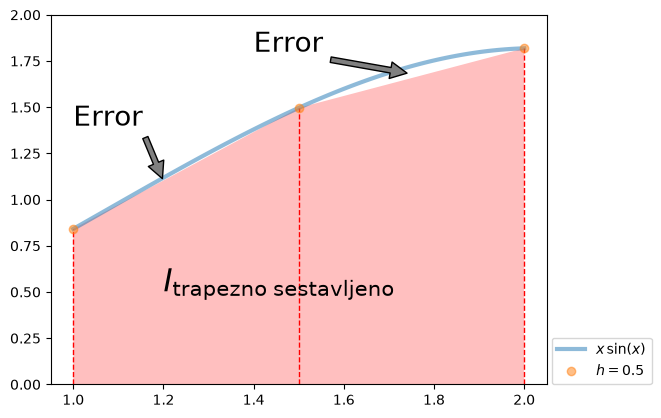

In [15]:
fig_trapezoidal_comp()

#### Error of the composite trapezoidal rule

The error of the composite trapezoidal rule stems from the error of the trapezoidal rule; here we make such an error $n$ times.

Since $h\cdot n=b-a$ holds, we derive the error of the composite trapezoidal rule as:

$$E_{\textrm{trapezno sest}}=-\frac{h^2(b-a)}{12}f''(\eta),$$

$\eta$ is a value on the interval $[a,b]$. The error is of second order $\mathcal{O}(h^2)$.

#### A better approximation of the integral

Next we will look at the so-called **Richardson extrapolation**, in which we compute a better approximation from the integral estimates with step $h$ and $2h$.

If we compute the integral $I$ numerically at two different steps $h$ and $2\,h$, the following holds:

$$\int_a^b f(x)\,\textrm{d}x = I_h + E_h = I_{2h} + E_{2h},$$

where $I_h$ and $I_{2h}$ are the approximations of the integral with step $h$ and $2h$, and $E_h$ and $E_{2h}$ are the error estimates at step $h$ and $2h$. We derive $I_{2h}-I_{h} = E_{h}-E_{2h}$

Next we write:

$$E_h=-\frac{h^2(b-a)}{12}f''(\eta)=h^2\,K.$$

Under the assumption that $f''\left (\eta \right )$ is the same at step $h$ and $2h$ ($\eta$ is actually different at step $h$ and $2h$), we write:

$$E_{2h}=-\frac{(2h)^2(b-a)}{12}f''(\eta)=4\,h^2\,K$$

It follows that:

$$I_{2h}-I_h=-3K\,h^2.$$

Now we can estimate the error at step $h$:

$$E_h=h^2\,K=\frac{I_h-I_{2h}}{3}.$$

Based on the error estimate, we can compute a better numerical approximation $I_{h}^*$:

$$I_h^* = I_h + \frac{1}{3}\,(I_{h}-I_{2h})$$

or

$$I_h^* = \frac{4}{3}\,I_h - \frac{1}{3}\,I_{2h}$$

#### Numerical example

We previously computed the integral with the trapezoidal rule at step $h=1$ and at step $h=0.5$ already; the results were:

In [16]:
[I_trapezoidal, I_trapezoidal_comp]

Using the formula above, we compute a better approximation:

In [17]:
I_trapezoidal_better = 4/3*I_trapezoidal_comp - 1/3*I_trapezoidal
print(f'Exact result:        {I_exact}\nBetter approximation: {I_trapezoidal_better}')

Exact result:        1.4404224209802097
Better approximation: 1.4408392930139313


The composite trapezoidal rule is also implemented in the ``numpy`` package, via the ``numpy.trapezoid`` function (``numpy.trapz`` in older versions):

```python
trapezoid(y, x=None, dx=1.0, axis=-1)
```

* `y` represents the table of function values,
* `x` is an optional parameter and defines the nodes; if the parameter is not defined, equidistant nodes spaced by `dx` are assumed,
* `dx` defines the (constant) integration step, with a default value of 1,
* `axis` defines the *axis* along which to integrate (in case `y` is a multidimensional numeric array).

The function returns the computed integral according to the composite trapezoidal rule. More information can be found in the [documentation](https://numpy.org/doc/stable/reference/generated/numpy.trapezoid.html).

#### ``numpy`` implementation of the composite trapezoidal rule

Let us look at an example:

In [18]:
#%%timeit
I_trapezoidal_np = np.trapezoid(y3v, dx=h3v)
I_trapezoidal_np

### Simpson's and other methods

Above we looked at the trapezoidal rule, which is based on a linear interpolating function on an individual subinterval. With higher-order interpolation we can derive further integration methods.

We need to compute:

$$\int_{a}^b f(x)\,dx.$$

We tabulate the integrand $f(x)$ and interpolate the table with the Lagrange interpolating polynomial $P_n(x)$ of degree $n$:

$$P_n(x)=\sum_{i=0}^{n}\,f(x_i)\,l_i(x),$$

where $y_i=f(x_i)$ are the function values at the nodes $x_i$ and the Lagrange polynomial $l_i$ is defined as:

$$l_i(x)=\prod_{j=0, j\ne i}^n \frac{x-x_j}{x_i-x_j}.$$

For the numerical computation of the integral $\int_{a}^b f(x)\,dx$ (the limits are: $a=x_0$, $b=x_n$), instead of the function $f(x)$ we substitute the interpolating polynomial $P_n(x)$ into the integral:

$$I=\int_{x_0}^{x_{n}} P_n(x)\,dx=\int_{x_0}^{x_{n}} \sum_{i=0}^{n}\,f(x_i)\,l_i(x)\,dx.$$

Since integration is a linear operation, we can swap the integration and the sum:

$$I=\sum_{i=0}^{n}\,f(x_i)\,\underbrace{\int_{x_0}^{x_{n}} l_i(x)\,dx}_{A_i}.$$

We integrate the Lagrange polynomial and obtain the weights $A_i$:

$$A_i = \int_{x_0}^{x_{n}} l_i(x)\,dx$$

#### Derivation of the trapezoidal rule using Lagrange polynomials

Let us look at how we can computationally derive the weights $A_i$ for the case of the trapezoidal rule using a first-degree Lagrange interpolating polynomial.

First, let us define the variable `x`, the nodes `x0` and `x1`, and the step `h` in symbolic form:

In [19]:
x, x0, x1, h = sym.symbols('x x0, x1, h')

Let us prepare a Python function that returns, in symbolic form, a list of $n$ coefficients of the Lagrange polynomials $[l_0(x), l_1(x),\dots, l_{n-1}(x)]$ of degree $n-1$:

In [20]:
def lagrange(n, x, nodes_prefix='x'):
    if isinstance(nodes_prefix, str):
        nodes = sym.symbols(f'{nodes_prefix}:{n}')
    coeffs = []
    for i in range(0, n):
        numer = []
        denom = []

        for j in range(0, n):
            if i == j:
                continue

            numer.append(x    - nodes[j])
            denom.append(nodes[i] - nodes[j])

        numer = sym.Mul(*numer)
        denom = sym.Mul(*denom)

        coeffs.append(numer/denom)
    return coeffs

First, let us look at the Lagrange polynomials for linear interpolation ($n=2$):

In [21]:
lag = lagrange(2, x)
lag

Now we integrate the Lagrange polynomial $l_0(x)$ over the entire interval:

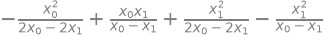

In [22]:
int0 = sym.integrate(lag[0], (x, x0, x1))
int0

We simplify the expression and obtain:

In [23]:
int1 = int0.factor()
int1

Since the width of the subinterval is constant, $x_1=h_0+h$, we perform the substitution:

In [24]:
substitutions = {x1: x0+h}
int1.subs(substitutions)

The steps above for the Lagrange polynomial $l_0(x)$ can be generalized to a list of Lagrange polynomials:

In [25]:
x, x0, x1, h = sym.symbols('x, x0, x1, h')
substitutions = {x1: x0+h}
A_trapezoid = [sym.integrate(li, (x, x0, x1)).factor().subs(substitutions)
            for li in lagrange(2, x)]  # for each Lagrange polynomial `li` in the list lagrange(2,x)
A_trapezoid

We derived the weights that we used in the trapezoidal method:

$$A_0=h/2\qquad A_1=h/2.$$

The trapezoidal rule is:

$$I_{\textrm{trapezno}}=\frac{h}{2}\left(y_0+y_1\right)$$

The error estimate is (reference: Burden, Faires, Burden: Numerical Analysis 10th Ed):

$$E_{\textrm{trapezno}}= -\frac{h^3}{12}f''(\xi).$$

#### Computing the weights for Simpson's rule

After showing the concise computation for the trapezoidal rule above, we can proceed similarly for quadratic interpolation over three points ($n=3$).

The computation of the weights is analogous to the one above:

In [26]:
x, x0, x1, x2, h = sym.symbols('x, x0, x1, x2, h')
substitutions = {x1: x0+h, x2: x0+2*h}
A_Simpson1_3 = [sym.integrate(li, (x, x0, x2)).factor().subs(substitutions).factor()
             for li in lagrange(3, x)]
A_Simpson1_3

Simpson's rule (this rule is also called Simpson's 1/3 rule) is:

$$I_{\textrm{Simpsonovo}}=\frac{h}{3}\left(y_0+4\,y_1+y_2\right)$$

The error estimate is (reference: Burden, Faires, Burden: Numerical Analysis 10th Ed):

$$E_{\textrm{Simpsonovo}}= -\frac{h^5}{90}f^{(4)}(\xi).$$

It should be pointed out that the error is locally of fifth order $\mathcal{O}(h^5)$ and is defined by the unknown value of the fourth derivative $f^{(4)}(\xi)$; consequently, this rule is exact for polynomials of degree 3 or less.

Example of use:

In [27]:
I_Simps = h3v/3 * np.sum(y3v * [1, 4, 1])
I_Simps

Let us prepare a figure. Since Simpson's rule is based on quadratic interpolation, we must first prepare the interpolating polynomial (we use ``scipy.interpolate``):

In [28]:
from numpy.polynomial import Polynomial # interpolating polynomial through the nodes

In [29]:
def fig_simpson():
    y_interpolate = Polynomial.fit(x3v, y3v, deg=len(x3v)-1)
    plt.fill_between(xg, y_interpolate(xg), alpha=0.25, facecolor='r')
    plt.vlines(x3v, 0, y3v, color='r', linestyles='dashed', lw=1)
    plt.annotate('$I_{\\mathrm{Simpsonovo}}$', (1.2, 0.5), fontsize=22)
    plt.annotate('Error', fontsize=20, xy=(1.75, 1.7), xytext=(1.4, 1.8),
            arrowprops=dict(facecolor='gray', shrink=0.05))
    plt.annotate('Error', fontsize=20, xy=(1.2, 1.1), xytext=(1., 1.4),
            arrowprops=dict(facecolor='gray', shrink=0.05))
    plt.plot(xg, yg, lw=3, alpha=0.5, label='$x\\,\\sin(x)$')
    plt.plot(x3v, y3v, 'o', alpha=0.5, label=f'$h={h3v}$')
    plt.legend(loc=(1.01, 0))
    plt.ylim(0, 2)
    plt.show()

We display:

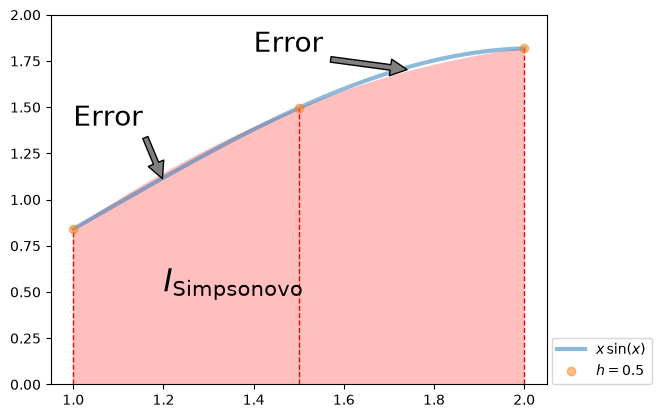

In [30]:
fig_simpson()

#### `scipy.integrate.newton_cotes`

The coefficients of the Newton-Cotes integration approach can also be obtained using `scipy.integrate.newton_cotes()` ([documentation](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.newton_cotes.html#scipy.integrate.newton_cotes)):

```python
newton_cotes(rn, equal=0)
```

where the parameters are:

* `rn`, which defines the number of subintervals (a non-constant step is also possible, see the [documentation](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.newton_cotes.html#scipy.integrate.newton_cotes)),
* `equal`, which defines whether equally wide subintervals are required.

The function returns a tuple, in which the first element represents the numeric array of weights and the second element the error estimate.

Let us look at an example:

In [31]:
from scipy import integrate
integrate.newton_cotes(2)

(array([0.33333333, 1.33333333, 0.33333333]), -0.011111111111111112)

#### Computing the weights for Simpson's 3/8 rule

We can continue with cubic interpolation over four points ($n=4$):

In [32]:
x, x0, x1, x2, x3, h = sym.symbols('x, x0, x1, x2, x3, h')
substitutions = {x1: x0+h, x2: x0+2*h, x3: x0+3*h}
A_Simpson3_8 = [sym.integrate(li, (x, x0, x3)).factor().subs(substitutions).factor()
                for li in lagrange(4, x)]
A_Simpson3_8

Simpson's 3/8 rule is:

$$I_{\textrm{Simpsonovo 3/8}}=\frac{3h}{8}\left(y_0+3\,y_1+3\,y_2+y_3\right)$$

The error estimate is (reference: Burden, Faires, Burden: Numerical Analysis 10th Ed):

$$E_{\textrm{Simpsonovo 3/8}}= -\frac{3\,h^5}{80}f^{(4)}(\xi).$$

Let us look at an example of use. We use the previously prepared table of function values at four points:

In [33]:
y4v

array([0.84147098, 1.2959172 , 1.65901326, 1.81859485])

In [34]:
I_Simps38 = 3*h4v/8 * np.sum(y4v * [1, 3, 3, 1])
I_Simps38

Let us also prepare a plot:

In [35]:
def fig_simpson38():
    y_interpolate = Polynomial.fit(x4v, y4v, deg=len(x4v)-1)
    plt.fill_between(xg, y_interpolate(xg), alpha=0.25, facecolor='r')
    plt.vlines(x4v, 0, y4v, color='r', linestyles='dashed', lw=1)
    plt.annotate('$I_{\\mathrm{Simpsonovo\\;3/8}}$', (1.2, 0.5), fontsize=22)
    plt.annotate('Error', fontsize=20, xy=(1.75, 1.7), xytext=(1.4, 1.8),
            arrowprops=dict(facecolor='gray', shrink=0.05))
    plt.annotate('Error', fontsize=20, xy=(1.5, 1.47), xytext=(1.1, 1.6),
            arrowprops=dict(facecolor='gray', shrink=0.05))
    plt.annotate('Error', fontsize=20, xy=(1.2, 1.1), xytext=(1., 1.4),
            arrowprops=dict(facecolor='gray', shrink=0.05))
    plt.plot(xg, yg, lw=3, alpha=0.5, label='$x\\,\\sin(x)$')
    plt.plot(x4v, y4v, 'o', alpha=0.5, label=f'$h={h4v:.6f}$')
    plt.legend(loc=(1.01, 0))
    plt.ylim(0, 2)
    plt.show()

We display:

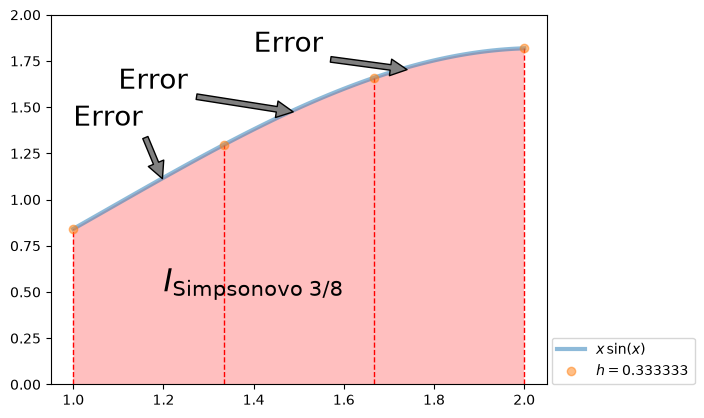

In [36]:
fig_simpson38()

### Composite Simpson's rule

We divide the interval $[a, b]$ into an even number $n$ of subintervals of equal width $h=(b - a)/n$, which defines the nodes $x_i=a+i\,h$ for $i=0,1,\dots,n$. In this case we write the composite Simpson's rule:

$$\int_{a}^{b}f(x)\,\textrm{d}x=
\frac{h}{3}\left(
f(x_0)
+4\sum_{i=1}^{n/2}f(x_{2i-1})
+2\sum_{i=1}^{n/2-1}f(x_{2i})
+f(x_n)
\right)
\underbrace{
-\frac{b-a}{180}h^4\,f^{(4)}(\eta)
}_{E_{\textrm{Sestavljeno Simpsonovo 1/3}}}
,$$

where $\eta$ is an unknown value on the interval $[a, b]$. The error is of fourth order $\mathcal{O}(h^4)$.

Numerical implementation:

In [37]:
def simpson_comp(y, h):
    """
    Composite Simpson's rule of integration.

    :param y: function values
    :param h: integration step
    """
    return h/3 * (y[0] + 4*np.sum(y[1:-1:2]) + 2*np.sum(y[2:-1:2]) + y[-1])

In [38]:
I_Simps_comp = simpson_comp(y5v, h=h5v)
I_Simps_comp

Let us prepare a figure:

In [39]:
def fig_simpson_comp():
    y_interpolate = Polynomial.fit(x5v, y5v, deg=len(x5v)-1)
    plt.fill_between(xg, y_interpolate(xg), alpha=0.25, facecolor='r')
    plt.vlines(x5v, 0, y5v, color='r', linestyles='dashed', lw=1)
    plt.annotate('$I_{\\mathrm{Simpsonovo\\;sestavljeno}}$', (1.2, 0.5), fontsize=22)
    plt.annotate('Error', fontsize=20, xy=(1.70, 1.68), xytext=(1.4, 1.8),
            arrowprops=dict(facecolor='gray', shrink=0.05))
    plt.plot(xg, yg, lw=3, alpha=0.5, label='$x\\,\\sin(x)$')
    plt.plot(x5v, y5v, 'o', alpha=0.5, label=f'$h={h5v}$')
    plt.legend(loc=(1.01, 0))
    plt.ylim(0, 2)
    plt.show()

We display:

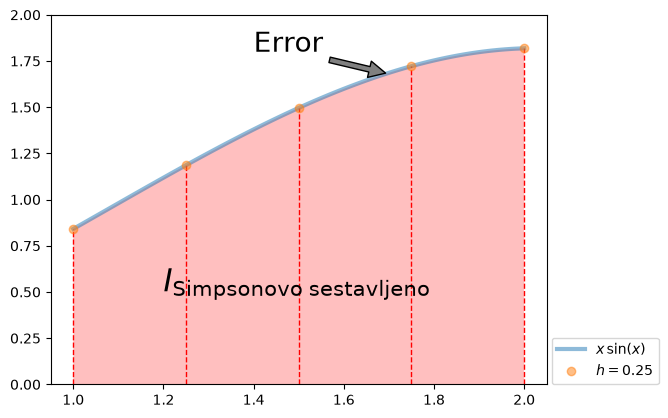

In [40]:
fig_simpson_comp()

#### A better estimate of the integral

The error of the composite Simpson's method is defined by:

$$E_{\textrm{Sestavljeno Simpsonovo 1/3}}=
-\frac{b-a}{180}h^4\,f^{(4)}(\eta),$$

where $\eta$ is an unknown value on the interval $[a, b]$.

We determine an improved estimate of the integral in a manner similar to the composite trapezoidal method; we estimate the integral $I$ at two different steps $h$ and $2\,h$, and the following holds exactly:

$$\int_a^b f(x)\,\textrm{d}x = I_h + E_h = I_{2h} + E_{2h},$$

where $I_h$ is the approximation of the integral with step $h$ and $E_h$ is the error estimate at step $h$; the same holds analogously for $I_{2h}$ and $E_{2h}$.

If we assume that $f^{(4)}\left (\eta \right )$ is the same in both cases, we can determine the difference $I_{2h}-I_{h} = E_{h}-E_{2h}$.

Next we write:

$$E_h=-\frac{b-a}{180}h^4\,f^{(4)}(\eta)=h^4\,K.$$

Under the assumption that $f^{(4)}\left (\eta \right )$ is the same at step $h$ and $2h$ ($\eta$ is actually different at step $h$ and $2h$), we write:

$$E_{2h}=-\frac{(b-a)}{180}(2h)^4\,f^{(4)}(\eta)=16\,h^4\,K$$

It follows that:

$$I_{2h}-I_h=-15K\,h^4.$$

Now we can estimate the error at step $h$:

$$E_h=h^4\,K=\frac{I_h-I_{2h}}{15}.$$

Based on the error estimate, we can compute a better approximation $I_{h}^*$:

$$I_h^* = I_h + \frac{1}{15}\,(I_{h}-I_{2h})$$

or

$$I_h^* = \frac{16}{15}\,I_h - \frac{1}{15}\,I_{2h}$$

#### Numerical example

We previously computed the integral with Simpson's rule at step $h=0.5$ and at step $h=0.25$ already; the results were:

In [41]:
[I_Simps, I_Simps_comp]

Using the formula above, we compute a better approximation:

In [42]:
I_Simps_better = 16/15*I_Simps_comp - 1/15*I_Simps
print(f'Exact result:        {I_exact}\nBetter approximation: {I_Simps_better}')

Exact result:        1.4404224209802097
Better approximation: 1.4404218714139077


We obtain a better numerical approximation, but we lose the error estimate!

#### Simpson's method in ``scipy.integrate.simpson``

The composite Simpson's rule is implemented in ``scipy`` in `scipy.integrate.simpson()` ([documentation](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.simpson.html)):

```python
simpson(y, x=None, *, dx=1.0, axis=-1)
```

where the parameters are:

* `y` the table of function values that we integrate,
* `x` the nodes, an optional parameter; if `x=None`, equidistant subintervals of width `dx` are assumed,
* `dx` the width of the equidistant subintervals, i.e., the integration step,
* `axis` the integration axis (important in the case of a multidimensional numeric array).

In older SciPy versions the function was called `simps` and also had the parameter `even`; both were removed in SciPy 1.14.

Let us look at an example; first we import the `simpson` function:

In [43]:
from scipy.integrate import simpson

In [44]:
#%%timeit
simpson(y5v, dx=h5v)

### Romberg method

The Romberg method is based on Richardson extrapolation. Let us assume that we integrate the integral $\int_a^b f(x)\textrm{d}x$ on the interval $[a,b]$, which we divide into $2^{n-1}$ subintervals ($n=1,2,4,8, \dots$).

We denote the result of the trapezoidal rule at $n=1$ by $R_{\underbrace{1}_{n},\underbrace{1}_{j}}$, where $j$ denotes the accuracy of the obtained result $\mathcal{O}(h^{2j})$.

If we apply the trapezoidal integration rule at $n=1,2,4 \dots$ subintervals, we compute:

* $R_{1,1}$, step $h_1=h$, order of accuracy $\mathcal{O}(h_1^2)$,
* $R_{2,1}$, step $h_2=h/2$, order of accuracy $\mathcal{O}(h_2^2)$,
* $R_{3,1}$, step $h_3=h/4$, order of accuracy $\mathcal{O}(h_3^2)$,
* $R_{4,1}$, step $h_4=h/8$, order of accuracy $\mathcal{O}(h_4^2)$,
* $\dots$
* $R_{n,1}$, step $h_4=h/(2^{n-1})$, order of accuracy $\mathcal{O}(h_n^2)$.

Based on Richardson extrapolation we compute a better approximation

* $R_{2,2} = R_{2,1} + \frac{1}{3}\left(R_{2,1}-R_{1,1}\right)$, step $h_2=h/2$, order of accuracy $\mathcal{O}(h_2^4)$,
* $R_{3,2} = R_{3,1} + \frac{1}{3}\left(R_{3,1}-R_{2,1}\right)$, step $h_3=h/4$, order of accuracy $\mathcal{O}(h_3^4)$,
* $\dots$
* $R_{n,2} = R_{n,1} + \frac{1}{3}\left(R_{n,1}-R_{n-1,1}\right)$, step $h_n=h/(2^{n-1})$, order of accuracy $\mathcal{O}(h_n^4)$.


Then we continue with Richardson extrapolation:

* $R_{3,3} = R_{3,2} + \frac{1}{15}\left(R_{3,2}-R_{2,2}\right)$, step $h_3=h/4$, order of accuracy $\mathcal{O}(h_3^6)$,
* $\dots$
* $R_{n,3} = R_{n,2} + \frac{1}{15}\left(R_{n,2}-R_{n-1,2}\right)$, step $h_n=h/(2^{n-1})$, order of accuracy $\mathcal{O}(h_n^6)$.


Richardson extrapolation can be generalized:

* $R_{n,j} = R_{n,j-1} + \frac{1}{4^{j-1}-1}\left(R_{n,j-1}-R_{n-1,j-1}\right)$, step $h_n=h/(2^{n-1})$, order of accuracy $\mathcal{O}(h_n^{2j})$


Here, the better approximation $R_{2,2}$ at step $h/2$ is equal to the result obtained by Simpson's method at step $h/2$. Similarly, the better approximation $R_{3,2}$ at step $h/4$ is equal to the numerical integral of Simpson's method at step $h/4$. And further, $R_{3,3}$ is equal to the corrected approximation of Simpson's method at step $h/4$.

Let us prepare the numerical data:

In [45]:
x9v, h9v = np.linspace(1, 2, 9, retstep=True)  # step h9v = 0.125 (9 nodes)
y9v = x9v * np.sin(x9v)

Let us look at the example from above. First, we compute the integral with the composite trapezoidal method at different steps (second-order error):

In [46]:
## O(h^2)
R1_1 = trapezoidal_comp(y9v[::8], 8*h9v) # h=1.0
R2_1 = trapezoidal_comp(y9v[::4], 4*h9v) # h=0.5
R3_1 = trapezoidal_comp(y9v[::2], 2*h9v) # h=0.25
R4_1 = trapezoidal_comp(y9v, h9v) # h=0.125
[R1_1, R2_1, R3_1, R4_1]

Then we compute better approximations (we obtain a fourth-order error):

In [47]:
## O(h^4)
R2_2 = R2_1 + 1/3 * (R2_1 - R1_1)
R3_2 = R3_1 + 1/3 * (R3_1 - R2_1)
R4_2 = R4_1 + 1/3 * (R4_1 - R3_1)
[R2_2, R3_2, R4_2]

The results represent the result of Simpson's method at step $h=0.5$, $h=0.25$ and $h=0.125$:

In [48]:
[simpson_comp(y9v[::4], 4*h9v), simpson_comp(y9v[::2], 2*h9v), simpson_comp(y9v, h9v)]

We again compute better approximations (we obtain a sixth-order error):

In [49]:
## O(h6)
R3_3 = R3_2 + 1/15 * (R3_2 - R2_2)
R4_3 = R4_2 + 1/15 * (R4_2 - R3_2)

[R3_3, R4_3]

The result represents the better result of Simpson's method at step $h=0.25$ and $h=0.125$:

In [50]:
a4h, a2h, ah = [simpson_comp(y9v[::4], 4*h9v), simpson_comp(y9v[::2], 2*h9v), simpson_comp(y9v, h9v)]
[16/15*a2h-1/15*a4h, 16/15*ah-1/15*a2h]

We again compute better approximations (we obtain an eighth-order error):

In [51]:
## O(h8)
R4_4 = R4_3 + 1/63 * (R4_3 - R3_3)
R4_4

The Romberg method thus offers high result accuracy at a relatively low numerical cost. The error is estimated by:

$$E = \left|R_{n,n}-R_{n-1,n-1}\right|.$$

#### Romberg method in ``scipy.integrate.romb``

The Romberg method is implemented in ``scipy`` in `scipy.integrate.romb()` ([documentation](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.romb.html#scipy.integrate.romb)):

```python
romb(y, dx=1.0, axis=-1, show=False)
```

where the parameters are:

* `y` the table of function values that we integrate,
* `dx` the width of the equidistant subintervals, i.e., the integration step,
* `axis` the integration axis (important in the case of a multidimensional numeric array),
* `show` if `True`, displays the elements of the Richardson extrapolation.

Let us look at the example from above:

In [52]:
from scipy.integrate import romb

In [53]:
y9v

array([0.84147098, 1.01505104, 1.18623077, 1.34872795, 1.49624248,
       1.62261343, 1.72197541, 1.78891084, 1.81859485])

In [54]:
romb(y9v, dx=h9v, show=True)

Richardson Extrapolation Table for Romberg Integration
 1.33003 
 1.41314  1.44084 
 1.43362  1.44045  1.44042 
 1.43872  1.44042  1.44042  1.44042 


## Gaussian integration approach

The Newton-Cotes approach is based on a polynomial of degree $n$, and the error is of degree $n+1$. This means that the integration yields an exact result if the integrated function is a polynomial of degree $n$ or less; for even $n$, owing to symmetry, even of degree $n+1$ (Simpson's rule, $n=2$, is e.g. exact also for cubic polynomials).

The Gaussian integration approach is fundamentally different: the goal is to replace the integral of the function $f(x)$ with a weighted sum of function values at discrete values $f(x_i)$:

$$\int_a^bf(x)\,\textrm{d}x\approx \sum_{i=0}^{n-1} A_i\, f(x_i).$$

Here both the weight $A_i$ and the location of the node $x_i$ are unknown. For polynomials of degree $n$ we will also need more points $(x_i, f(x_i))$.

In what follows, we will learn that we can compute a numerically exact integral very efficiently. An additional advantage of Gaussian integration is that it can compute the integral of functions with singularities (e.g.: $\int_0^1\sin(x)/\sqrt{(x)}\,dx$).

### Gaussian quadrature with one node

Let us assume that we want to integrate a polynomial of degree $n=1$ (a linear function):

$$f(x)=P_1(x)=a_0+a_1\,x.$$

Let us compute:

$$\int_{x_L}^{x_D}P_1(x)\,\textrm{d}x=\left(a_0\,x+a_1\,\frac{x^2}{2}\right)_{x_L}^{x_D}=-a_0\,x_L+a_0\,x_D-\frac{a_1\,x_L^2}{2}+\frac{a_1\,x_D^2}{2}.$$

On the other hand, we want to compute the integral from the appropriately weighted $A_0$ value of the function $f(x_0)$ at an unknown node $x_0$ (only one node!):

$$\int_{x_L}^{x_D}P_1(x)\,\textrm{d}x = A_0\,P_1(x_0)= A_0\,a_0+A_0\,a_1\,x_0.$$

By equating the expressions above, we derive:

$$-a_0\,x_L+a_0\,x_D-\frac{a_1\,x_L^2}{2}+\frac{a_1\,x_D^2}{2}=A_0\,a_0+A_0\,a_1\,x_0.$$

$a_0$ and $a_1$ are the coefficients of the linear function, which can take arbitrary values, so it holds that:

$$a_0\,\left(-x_L+x_D-A_0\right)=0\qquad\textrm{and}\qquad a_1\left(-\frac{x_L^2}{2}+\frac{x_D^2}{2}-A_0\,x_0\right)=0.$$

This is a system of linear equations with the solution:

$$A_0= x_D-x_L, \qquad x_0=\frac{x_L+x_D}{2}.$$

If the integrated function is linear, we will compute the true value based only on the value at a single point!

So that the Gaussian integration approach is independent of the integration limits $x_L$, $x_D$, we introduce standard limits.

#### Standard limits: $x_L=-1$ and $x_D=1$

For generality, we transform the limits $x\in[x_L, x_D]$ into $\xi\in[-1, +1]$ using:

$$x=\frac{x_D+x_L}{2}+\frac{x_D-x_L}{2}\xi$$

and

$$\textrm{d}x=\frac{x_D-x_L}{2}\textrm{d}\xi.$$

The following holds:

$$\int_{x_L}^{x_D}f(x)\,\textrm{d}x=\int_{-1}^1 g\left(\xi\right)\,\textrm{d}\xi,$$

where:

$$g(\xi)=\frac{x_D-x_L}{2}\,f\left(\frac{x_L+x_D}{2}+\frac{x_D-x_L}{2}\xi\right).$$

In the case of standard limits, at one Gauss point the weight is $A_0=2$ and $x_0=0$ is the value at which we must evaluate the function $f(x_0)$.

#### Computational derivation of the weights and the Gauss point

Let us define the symbols and set up the equation:

In [55]:
a_0, a_1, x, x_L, x_D, A_0, x_0 = sym.symbols('a_0, a_1, x, x_L, x_D, A_0, x_0') # symbols
P1 = a_0 + a_1*x                                                   # linear polynomial
eq = sym.Eq(P1.integrate((x, x_L, x_D)).expand(), A_0*P1.subs(x, x_0)) # theoretical integral = estimate with weights
eq

Let us prepare two equations (for the first we assume $a_0=0, a_1=1$, for the second we assume $a_0=1, a_1=0$) and solve the system for `A_0` and `x_0`:

In [56]:
sym.solve([eq.subs(a_0, 0).subs(a_1, 1), eq.subs(a_1, 0).subs(a_0, 1)], [A_0, x_0])

For additional explanation, I recommend this [video](https://www.youtube.com/watch?v=iQ5-4hx25Rw).

### Gaussian integration method with multiple nodes

We want to derive a Gaussian integration method that will take into account $v$ nodes on the interval $[a,b]$ and will exactly compute the integral of polynomials up to degree $n=2v-1$. The following must hold:

$$\int_a^bP_{2v-1}(x)\,\textrm{d}x = \sum_{i=0}^{v-1} A_i\,P_{2v-1}(x_i).$$

In the derivation we will restrict ourselves to the standard limits $x_L=-1$, $x_D=1$,

where the polynomial of degree $n=2v-1$ is defined as:

$$P_{2v-1}(x)=\sum_{i=0}^{2v-1} a_i\,x^i.$$

With two Gauss points/nodes we exactly compute the integral of a polynomial up to third order, and with three Gauss nodes we exactly compute the integral of a polynomial up to fifth order!

#### Computational derivation
Let us first prepare the symbolic notation of the polynomial and the corresponding variables:

In [57]:
def P_etc(n=1, a='a', x='x'):                       # n is the degree of the polynomial
    ai = sym.symbols(f'{a}:{n+1}')                  # list of a_i
    x = sym.symbols(x)                              # variable x
    return ai, x, sum([ai[i]*x**i for i in range(n+1)])

Now let us find the weights $A_i$ and the nodes $x_i$ for the case of two Gauss nodes; the polynomial is therefore of third degree.

In [58]:
v = 2 # number of nodes
ai, x, P = P_etc(n=2*v-1)
xi = sym.symbols(f'x:{v}') # list of x_i
Ai = sym.symbols(f'A:{v}') # list of A_i
print(f'Nodes:   {xi}\nWeights: {Ai}')

Nodes:   (x0, x1)
Weights: (A0, A1)


The polynomial:

In [59]:
P

Similarly to the one node above, here let us define the equations:

In [60]:
eqs = [sym.Eq(P.integrate((x, -1, 1)).coeff(a_),\
              sum([Ai[i]*P.subs(x, xi[i]) \
                   for i in range(v)]).expand().coeff(a_)) \
       for a_ in ai]
eqs

We solve them for the unknown $x_i$ and $A_i$:

In [61]:
sol = sym.solve(eqs, sym.flatten((xi, Ai)))
sol

We determined a list of two (equal) solutions.

First, the nodes are defined: $x_0=-\sqrt{3}/3$ and $x_1=\sqrt{3}/3$, with the corresponding weights $A_0=A_1=1$.

The code above is derived in general - you can increase the number of nodes `v` and compute the nodes and the corresponding weights.

Below is a table of nodes and weights for one, two, and three nodes (for the limits $a=-1$, $b=1$):


**Number of points 1:**

| $i$ | Node  $x_i$ | Weight $A_i$ |
|:------------:|:------------:|:------------:|
|0 | 0 | 2 |


**Number of points 2:**

| $i$ | Node  $x_i$ | Weight $A_i$ |
|:------------:|:------------:|:------------:|
|0 | $-\frac{\sqrt{3}}{3}$ | 1 |
|1 | $+\frac{\sqrt{3}}{3}$ | 1 |

**Number of points 3:**

| $i$ | Node  $x_i$ | Weight $A_i$ |
|:------------:|:------------:|:------------:|
|0 | $-\frac{\sqrt{15}}{5}$ | $\frac{5}{9}$ |
|1 | $0$ | $\frac{8}{9}$ |
|2 | $\frac{\sqrt{15}}{5}$ | $\frac{5}{9}$ |

For more nodes and also the error estimate, see [Mathworld  Legendre-Gauss Quadrature](http://mathworld.wolfram.com/Legendre-GaussQuadrature.html).

For the case of three Gauss points, we compute the numerical integral (standard limits):

$$I_{\textrm{Gauss3}}= \frac{5}{9}\,f\left(-\frac{\sqrt{15}}{5}\right) + \frac{8}{9}\,f\left(0\right)+\frac{5}{9}\,f\left(\frac{\sqrt{15}}{5}\right).$$

#### Numerical implementation

The numerical implementation (including the transformation of the limits) for one, two, or three nodes:

In [62]:
def gaussian(fun, a, b, nodes=1):
    """
    Gaussian integration method.

    :param fun: object of the function to integrate
    :param a:   lower limit
    :param b:   upper limit
    :param nodes: number of nodes (1, 2, or 3)
    """
    def g(xi): # function for transforming the limits
        return (b-a)/2 * fun((b+a +xi * (b-a))/2)

    if nodes == 1:
        return 2*g(0.)
    elif nodes == 2:
        return 1. * g(-np.sqrt(3)/3) + 1. * g(np.sqrt(3)/3)
    elif nodes == 3:
        return 5/9 * g(-np.sqrt(15)/5) +8/9 * g(0.) + 5/9 * g(np.sqrt(15)/5)

Let us look at an example. First, let us define the function we want to integrate:

In [63]:
def f(x):
    return x*np.sin(x)

Now we pass the function (in this concrete case `f`) and not the value (e.g., `f(0.)`) to the `gaussian` function. First for one node, then two and three:

In [64]:
gaussian(fun=f, a=1., b=2., nodes=1)

In [65]:
gaussian(fun=f, a=1., b=2., nodes=2)

In [66]:
gaussian(fun=f, a=1., b=2., nodes=3)

#### ``scipy.integrate.fixed_quad``

Within ``scipy``, the Gaussian integration method is implemented in the `scipy.integrate.fixed_quad()` function ([documentation](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.fixed_quad.html)):

```python
fixed_quad(func, a, b, args=(), n=5)
```

where the parameters are:

* `func` is the name of the function we call,
* `a` is the lower limit,
* `b` is the upper limit,
* `args` is a tuple of any additional arguments of the function `func`,
* `n` is the number of nodes of the Gaussian integration, default `n=5`.

The function returns a tuple with the integration result `val` and the value `None`: `(val, None)`

Let us look at the example from above:

In [67]:
from scipy.integrate import fixed_quad
fixed_quad(f, a=1, b=2, n=3)[0]

The result is equal to the previous one:

In [68]:
gaussian(fun=f, a=1., b=2., nodes=3)

## ``scipy.integrate``

``scipy.integrate`` is a powerful tool for numerical integration (see the [documentation](https://docs.scipy.org/doc/scipy/reference/integrate.html)). In what follows, we will look at some of the functions.

### Integration functions that require a defining *function*:

* `quad(func, a, b[, args, full_output, ...])`	computes the definite integral of `func(x)` over the limits [`a`, `b`],
* `dblquad(func, a, b, gfun, hfun[, args, ...])`	computes the definite integral of `func(x,y)`,
* `tplquad(func, a, b, gfun, hfun, qfun, rfun)`	computes the definite integral of `func(x,y,z)`,
* `nquad(func, ranges[, args, opts, full_output])`	computes the definite integral of the $n$-dimensional function `func( ...)`,

#### `scipy.integrate.quad`

Let us look at a very useful function for integration, `scipy.integrate.quad()` ([documentation](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.quad.html#scipy.integrate.quad)):

```python
quad(func, a, b, args=(), full_output=0, epsabs=1.49e-08, epsrel=1.49e-08, limit=50,
     points=None, weight=None, wvar=None, wopts=None, maxp1=50, limlst=50)
```

The selected parameters are:

* `func` the Python function we integrate,
* `a` the lower limit of integration (`np.inf` can be used for an infinite limit),
* `b` the upper limit of integration (`np.inf` can be used for an infinite limit),
* `full_output` to display all results, default 0,
* `epsabs` the allowed absolute error,
* `epsrel` the allowed relative error.

Let us look at the example from above:

In [69]:
from scipy import integrate

In [70]:
integrate.quad(f, a=1, b=2)

#### `scipy.integrate.dblquad`

This is a function similar to `quad`, but for integration over two variables ([documentation](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.dblquad.html#scipy.integrate.dblquad)).
The function `scipy.integrate.dblquad()` computes the double integral of `func(y, x)` over the limits from `x = [a, b]` and `y = [gfun(x), hfun(x)]`.

```python
dblquad(func, a, b, gfun, hfun, args=(), epsabs=1.49e-08, epsrel=1.49e-08)
```

The selected parameters are:

* `func` is the Python function we integrate,
* `a` is the lower limit of integration of `x` (`np.inf` can be used for an infinite limit),
* `b` is the upper limit of integration of `x` (`np.inf` can be used for an infinite limit),
* `gfun` is the Python function that defines the lower limit of `y` as a function of `x`,
* `hfun` is the Python function that defines the upper limit of `y` as a function of `x`.

Let us look at an example of computing the area of a half-circle with radius 1:

$$\int_{-1}^{1}\left(\int_0^{\sqrt{1-x^2}}1\,\textrm{d}y\right)\,\textrm{d}x=\frac{\pi}{2}$$

Let us define the appropriate Python functions and compute the result:

In [71]:
def func(y, x): # the integration function is simple, a constant = 1!
    return 1.
def gfun(x):    # lower limit = 0
    return 0.
def hfun(x):    # upper limit
    return np.sqrt(1-x**2)
integrate.dblquad(func=func, a=-1, b=1, gfun=gfun, hfun=hfun)

### Integration functions that require a table of values:

* `trapezoid(y[, x, dx, axis])` composite trapezoidal rule,
* `cumulative_trapezoid(y[, x, dx, axis, initial])` cumulative integral of the integrand (returns the result at each node),
* `simpson(y[, x, dx, axis])`	Simpson's method,
* `romb(y[, dx, axis, show])`	Romberg method.

Here we will look at the `cumulative_trapezoid` function on an example. Consider the case where a mass $m=1$ (we omit the units) acted upon by a force $F=\sin(t)$. From Newton's 2nd law it follows that: $F=m\,\ddot x$. We integrate the acceleration to compute the velocity; then we integrate once more for the displacement. Let us first define the function for the acceleration:

In [72]:
def acceleration(t):
    F = np.sin(t)
    m = 1
    return F/m

We are interested in what happens over a time of 3 seconds:

In [73]:
t, h = np.linspace(0, 3, 100, retstep=True)

Let us compute the table of accelerations and then integrate for the velocity (here it is important to define the initial value):

In [74]:
a = acceleration(t)
v = integrate.cumulative_trapezoid(y=a, dx=h, initial=0)

Now let us integrate the velocity once more to compute the path:

In [75]:
s = integrate.cumulative_trapezoid(y=v, dx=h, initial=0)

Let us display the result:

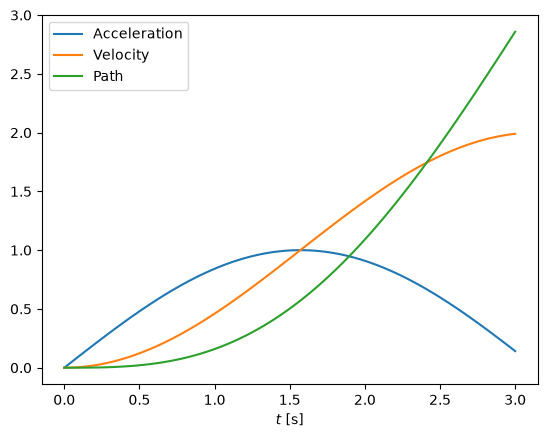

In [76]:
plt.plot(t, a, label='Acceleration')
plt.plot(t, v, label='Velocity')
plt.plot(t, s, label='Path')
plt.xlabel('$t$ [s]')
plt.legend();

---

# Practice questions

---

**Question 1:** Using the tools of the ``sympy`` package, symbolically determine the value of the first moment of area of a cross-section in the shape of a quarter circle shown in the figure:

$$S_{xx} = \int_{A}y~\text{d}A=\int_0^r \int_0^{\pi/2}y(\varphi)~r~\text{d}\varphi~\text{d}r = \int_{0}^{\pi/2}\frac{r^3}{3}\, \sin (\varphi)\, \text{d}\varphi$$

<img src="fig/vaje/cetrtina_kroga.png" style="width:340px">

Also prepare a numerical function for the dependence of the integrand $f(\varphi) = \Big(\frac{r^3}{3}\, \sin (\varphi) \Big)$ for a given value of the radius $R$.

*Data:*

$R = 7.5$ mm

**Question 2:** Use the numerical function prepared in the previous problem and compute and graphically display the values of the integrand from the first problem $\Big(f(\varphi) = \frac{r^3}{3}\sin (\varphi) \Big)$ at 100 discrete points on the interval $\varphi \in [0, \pi/2]$.

Also compute the value of the definite integral $S$ numerically, using the trapezoidal and Simpson's 1/3 methods from the ``numpy`` or ``scipy`` packages.

$$ S = \int_{0}^{\pi/2}\frac{r^3}{3}\sin (\varphi)\text{d}\varphi$$

--------

### Trapezoidal rule

**Question 3:** Using your own implementation of the trapezoidal rule (the basic one, not the composite one), compute the definite integral

$$I = \int_{0}^{2} -0.5x^3 - x^2 + 8 ~\text{d}x$$

Compare the obtained value with the result of the ``numpy.trapezoid`` function (or `scipy.integrate.trapezoid`), where you divide the observed interval into 10 equidistant segments.

---------

### Improved approximation with Richardson extrapolation:


$$\bar{I} = \frac{4I_h - I_{2h}}{3}$$

**Question 4** : Use Richardson extrapolation and determine a more accurate value of the integral from the previous problem by first dividing the observed interval $x \in [0, 2]$ into 2, then into 4 equidistant segments and using the composite trapezoidal method from the ``numpy`` package.

-----------

### Simpson's 1/3 rule

**Question 5:** Compute the definite integral from the previous problem with your own code of Simpson's 1/3 method (the basic one, not the composite one).

$$I = \int_{0}^{2} -0.5x^3 - x^2 + 8 ~\text{d}x$$

Compare the obtained value with the result of the ``scipy.integrate.simpson`` function, where you divide the observed interval into 7 equidistant points.

---

**Question 6:** The measured values of a car's acceleration in the direction of travel over time are given. Using the cumulative trapezoidal method (``scipy.integrate.cumulative_trapezoid``), determine the values of the velocity and the distance traveled by the car over the observed time interval.

At time $t = 0$ the car is at rest (hint: the ``initial`` argument).

In [82]:
#Data
t = np.linspace(0, 7, 10) # s
a = np.array([ 3.47,  4.03,  4.36,  4.48,  4.27,  3.78,  3.19,  2.73,  2.54,  2.53]) # m/s^2

---

## Gaussian integration method (Gaussian quadrature)

**Question 7:** Using the composite trapezoidal method from `scipy` and the Gaussian integration method (``scipy.integrate.quad``), compute the values of the integrals:

$$I_1 = \int_{0}^{1}\frac{\sin(x)}{x} \text{d}x$$

$$I_2 = \int_{1}^{2}\frac{\sin(x)}{x} \text{d}x$$

$$I_3 = \int_{-0.5}^{0.5}\frac{\sin(x)}{x} \text{d}x$$

When using the trapezoidal method, divide the observed interval into 10 points.

**Question 8:** Compute the integral:

$$I = \int_{-0.5}^{0.5}\frac{\sin(x)}{x} \text{d}x$$

using the ``scipy.integrate.fixed_quad`` function as well, to which you can also pass the parameter for the number of nodes in the integration, ``n``. First use integration with one node, then with two, and finally with three nodes.